# import library

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# merge data

In [ ]:
data_path = '/home/agung/Documents/alcr/ABC2026 Sozolab Challenge-20260110T085845Z-1-001/ABC2026 Sozolab Challenge/Dataset/BLE Data'

file_name = '4 day'

rssi_list = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16', '17','18','19','20', '21','22', '23','24','25']

mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

file_list = os.listdir(data_path)

csv_data = []
for csv_file in file_list:
  csv_data.append(pd.read_csv(os.path.join(data_path,csv_file),names=['user_id','timestamp','name', 'mac address', 'RSSI', 'power']))

df = csv_data[0]
for i in range(1,len(csv_data)):
  df = pd.concat([df,csv_data[i]])

print(df.shape)
df.head(5)

In [ ]:
# df.to_csv('df_concatenated.csv', index=False)

# load data

In [ ]:
df = pd.read_csv('../../dataset/df_concatenated.csv')
label = pd.read_csv('../../dataset/Dataset/5f_label_loc_train.csv')

# eda

In [ ]:
print(df.info())

print(label.info())

## rssi

In [ ]:
df.head(1)

In [ ]:
print(df['user_id'].value_counts())
print(df['name'].value_counts())

In [ ]:
print(df['mac address'].nunique())
print(df['power'].nunique())
print(df['RSSI'].nunique())

In [ ]:
plt.hist(df['power'])

In [ ]:
plt.hist(df['RSSI'])

## label

In [ ]:
label.head(1)

In [ ]:
print(label['activity'].value_counts())
print(label['user_id'].value_counts())
print(label['user'].value_counts())
print(label['room'].value_counts())
print(label['floor'].value_counts())

# preprocessing

## cleaning

In [ ]:
df = df.drop(columns=['name'])

label = label.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'user', 'floor'])

In [ ]:
# rename agar jelas
label = label.rename(columns={
    'started_at': 'start_time',
    'finished_at': 'stop_time'
})

# parse waktu
label['start_time'] = pd.to_datetime(label['start_time'], errors='coerce')
label['stop_time']  = pd.to_datetime(label['stop_time'], errors='coerce')

# hitung durasi
label['duration'] = (label['stop_time'] - label['start_time']).dt.total_seconds()

# filter valid
label = label[
    label['start_time'].notna() &
    label['stop_time'].notna() &
    (label['duration'] > 0) &
    label['deleted_at'].isna()
]

# hapus null penting & duplikat
label = label.dropna(subset=['room'])
label = label.drop_duplicates()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]

In [ ]:
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Tokyo')
label['start_time'] = label['start_time'].dt.tz_convert('Asia/Tokyo')
label['stop_time'] = label['stop_time'].dt.tz_convert('Asia/Tokyo')

In [ ]:
label = label.loc[label['activity'] == 'Location']
label = label.drop(columns=['deleted_at', 'updated_at', 'activity'])

In [ ]:
df = df.sort_values('timestamp').reset_index(drop=True)
label = label.sort_values('start_time').reset_index(drop=True)

In [ ]:
# ambil rentang label
start_label = label['start_time'].min()
end_label = label['stop_time'].max()

# potong RSSI ke rentang label
df = df[(df['timestamp'] >= start_label) & (df['timestamp'] <= end_label)].copy()

print(df['timestamp'].min(), df['timestamp'].max())

In [ ]:
print(start_label)
print(end_label)

In [ ]:
rooms = []
lbl = label.to_dict('records')
j = 0
n = len(lbl)

for ts in df['timestamp']:
    # geser interval label sampai stop_time >= ts
    while j < n and ts > lbl[j]['stop_time']:
        j += 1

    if j < n and lbl[j]['start_time'] <= ts <= lbl[j]['stop_time']:
        rooms.append(lbl[j]['room'])
    else:
        rooms.append(np.nan)

df['room'] = rooms

# buang RSSI tanpa label
df1 = df.dropna(subset=['room']).reset_index(drop=True)


In [ ]:
print(df1.shape)
print(df1['room'].value_counts())

In [ ]:
df1.info()

In [ ]:
df1.to_csv('../../dataset/df_cleaned.csv')

## feature engineering

In [2]:
df = pd.read_csv('../../dataset/df_cleaned.csv')

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]
df = df.drop(columns=['Unnamed: 0'])

In [4]:
mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

df = df[df['mac address'].isin(mac_list)]
df = df.sort_values('timestamp').reset_index(drop=True)

In [5]:
WINDOW = '45s'
df['window_start'] = df['timestamp'].dt.floor(WINDOW)

room_per_window = (
    df.groupby('window_start')['room']
      .nunique()
      .value_counts()
)

room_per_window

room
1    729
2    175
3     35
4      4
5      1
Name: count, dtype: int64

In [6]:
valid_windows = (
    df.groupby('window_start')['room']
      .nunique()
      .reset_index()
)

valid_windows = valid_windows[valid_windows['room'] == 1]['window_start']

df = df[df['window_start'].isin(valid_windows)].reset_index(drop=True)

df.groupby('window_start')['room'].nunique().value_counts()

room
1    729
Name: count, dtype: int64

In [7]:
# RSSI matrix: window x beacon
rssi_matrix = (
    df
    .groupby(['window_start', 'mac address'])['RSSI']
    .mean()              
    .unstack('mac address')
    .sort_index()
)

In [8]:
rssi_matrix

mac address,C6:CD:5E:3D:2F:BB,C8:5B:BF:37:07:A0,C9:17:55:E2:3E:0E,C9:EA:57:8B:0F:80,CA:60:AB:EE:EC:7F,CC:54:33:F6:A7:90,D4:33:FD:F4:C2:A8,D6:51:7F:AB:0E:29,D6:7C:1D:2C:2A:0A,D6:F4:3A:79:74:63,...,E5:CD:4A:36:87:06,E6:60:05:1F:88:F9,E6:99:D1:EC:C6:81,E6:F3:93:A8:9E:22,EA:09:20:80:D6:44,EA:66:A1:12:2C:F4,EB:20:56:87:04:5A,EE:E7:46:DC:19:6F,F6:DA:97:C7:D5:28,F7:7F:78:76:7E:F3
window_start,,,,,,,,,,,,,,,,,,,,,
2023-04-10 14:22:30+09:00,NaN,NaN,-94.812375,NaN,NaN,NaN,NaN,-96.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-10 14:24:45+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-99.000000,NaN,NaN,NaN,NaN,-98.00
2023-04-10 14:25:30+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-96.545455,NaN,-100.0,NaN,-96.213018,NaN,NaN,NaN,NaN,-96.75
2023-04-10 14:28:30+09:00,NaN,NaN,NaN,-91.780822,-93.512195,NaN,NaN,-93.522184,NaN,NaN,...,NaN,NaN,-99.0,NaN,NaN,NaN,NaN,-97.571429,-98.166667,NaN
2023-04-10 14:30:00+09:00,NaN,-91.714286,NaN,NaN,NaN,NaN,NaN,NaN,-86.200000,NaN,...,NaN,NaN,NaN,NaN,NaN,-97.500000,-92.428571,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-13 12:44:15+09:00,NaN,NaN,-89.833333,-96.363636,-95.000000,-95.000000,NaN,-90.500000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-97.000000,-97.000000,-94.136364,NaN,NaN
2023-04-13 12:45:00+09:00,NaN,NaN,-97.000000,NaN,NaN,NaN,NaN,-97.960000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-13 12:47:15+09:00,NaN,NaN,NaN,-98.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-95.000000,NaN,NaN


In [9]:
agg_funcs = ['min', 'max', 'count']
# agg_funcs = ['mean', 'std', 'var', 'min', 'max', 'median', 'sum', 'count']

feat = (
    df
    .groupby(['window_start', 'room', 'mac address'])['RSSI']
    .agg(agg_funcs)
    .unstack('mac address')
)

# flatten kolom: {mac}_{stat}
feat.columns = [f'{mac}_{stat}' for stat, mac in feat.columns]
feat = feat.reset_index()

In [10]:
feat

,window_start,room,C6:CD:5E:3D:2F:BB_min,C8:5B:BF:37:07:A0_min,C9:17:55:E2:3E:0E_min,C9:EA:57:8B:0F:80_min,CA:60:AB:EE:EC:7F_min,CC:54:33:F6:A7:90_min,D4:33:FD:F4:C2:A8_min,D6:51:7F:AB:0E:29_min,...,E5:CD:4A:36:87:06_count,E6:60:05:1F:88:F9_count,E6:99:D1:EC:C6:81_count,E6:F3:93:A8:9E:22_count,EA:09:20:80:D6:44_count,EA:66:A1:12:2C:F4_count,EB:20:56:87:04:5A_count,EE:E7:46:DC:19:6F_count,F6:DA:97:C7:D5:28_count,F7:7F:78:76:7E:F3_count
0,2023-04-10 14:22:30+09:00,kitchen,NaN,NaN,-101.0,NaN,NaN,NaN,NaN,-97.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-04-10 14:24:45+09:00,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,17.0
2,2023-04-10 14:25:30+09:00,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,187.0,NaN,34.0,NaN,169.0,NaN,NaN,NaN,NaN,68.0
3,2023-04-10 14:28:30+09:00,506,NaN,NaN,NaN,-99.0,-101.0,NaN,NaN,-101.0,...,NaN,NaN,34.0,NaN,NaN,NaN,NaN,119.0,102.0,NaN
4,2023-04-10 14:30:00+09:00,520,NaN,-96.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,34.0,119.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,2023-04-13 12:44:15+09:00,Clean Room,NaN,NaN,-93.0,-100.0,-95.0,-97.0,NaN,-91.0,...,NaN,NaN,NaN,NaN,NaN,24.0,6.0,132.0,NaN,NaN
725,2023-04-13 12:45:00+09:00,Clean Room,NaN,NaN,-99.0,NaN,NaN,NaN,NaN,-100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
726,2023-04-13 12:47:15+09:00,nurse station,NaN,NaN,NaN,-98.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN
727,2023-04-13 12:48:00+09:00,nurse station,NaN,NaN,-96.0,-98.0,-96.0,-98.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.0,NaN,NaN


In [11]:
feat['hour'] = feat['window_start'].dt.hour
feat['minute'] = feat['window_start'].dt.minute
feat['second'] = feat['window_start'].dt.second

In [12]:
feat = feat.fillna(-1)

# modelling

In [13]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [14]:
X = feat.drop(columns=['window_start', 'room'])
y = feat['room']

In [15]:
X.columns = (
    X.columns
    .str.replace(':', '_', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [16]:
min_samples = 2
valid_rooms = y.value_counts()[y.value_counts() >= min_samples].index

mask = y.isin(valid_rooms)
X = X[mask]
y = y[mask]

In [17]:
print(X.shape, y.shape)
X.iloc[:2, :5]
y.value_counts()

(728, 78) (728,)


room
nurse station    146
kitchen          127
Office Small      82
cafeteria         67
Cafeteria D       61
Office Large      39
hallway           31
523               31
201               17
513               16
213               13
520               12
512               11
208               11
210               10
522                9
Cafeteria B        8
cleaning           7
511                5
515                5
501                4
508                3
202                3
503                3
Bathroom           3
510                2
Clean Room         2
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)


In [20]:
models = {
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    # "SVM": SVC(kernel='rbf', probability=True),
    # "KNN": KNeighborsClassifier(n_neighbors=5),
    # "LR": LogisticRegression(max_iter=1000, n_jobs=-1),
    "HGBC": HistGradientBoostingClassifier(random_state=42)
}

models.update({
    "LGBM": lgb.LGBMClassifier(
        objective='multiclass',
        num_class=len(set(y_enc)),
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        objective='multi:softprob',
        num_class=len(set(y_enc)),
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='mlogloss',
        random_state=42
    )
})

In [21]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1414
[LightGBM] [Info] Number of data points in the train set: 509, number of used features: 69
[LightGBM] [Info] Start training from score -3.747541
[LightGBM] [Info] Start training from score -5.539301
[LightGBM] [Info] Start training from score -4.153006
[LightGBM] [Info] Start training from score -4.286538
[LightGBM] [Info] Start training from score -4.035223
[LightGBM] [Info] Start training from score -5.133836
[LightGBM] [Info] Start training from score -5.539301
[LightGBM] [Info] Start training from score -5.539301
[LightGBM] [Info] Start training from score -6.232448
[LightGBM] [Info] Start training from score -5.133836
[LightGBM] [Info] Start training from score -4.153006
[LightGBM] [Info] Start training from score -3.834553
[LightGBM] [Info] Start training from score -4.846154
[LightGBM] 

In [22]:
results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False)
results_df

,model,accuracy,precision,recall,f1,f1_macro
2,HGBC,0.648402,0.641940,0.648402,0.630032,0.555323
5,XGBoost,0.621005,0.583461,0.621005,0.590457,0.487990
3,LGBM,0.602740,0.590158,0.602740,0.578804,0.466232
0,DT,0.584475,0.582264,0.584475,0.576202,0.410126
4,CatBoost,0.593607,0.556936,0.593607,0.547996,0.337836
1,RF,0.543379,0.493061,0.543379,0.494939,0.311648


# hierarchical classification

In [23]:
# define hierarchy
hierarchy = {
    'Patient Room': ['201', '202', '208', '210', '213', '501', '503', '508', '510', '511', '512', '513', '515', '520', '522', '523'],
    'Non-Patient Room': ['nurse station', 'kitchen', 'Office Small', 'Office Large', 'cafeteria', 'Cafeteria B', 'Cafeteria D', 'hallway', 'Bathroom', 'cleaning', 'Clean Room']
}

# create reverse mapping: room -> level1
room_to_level1 = {}
for level1, rooms in hierarchy.items():
    for room in rooms:
        room_to_level1[room] = level1

print("Hierarchy mapping:")
for level1, rooms in hierarchy.items():
    print(f"\n{level1}:")
    print(f"  {rooms}")

print("\nRoom to Level1 mapping:")
print(room_to_level1)

Hierarchy mapping:

Patient Room:
  ['201', '202', '208', '210', '213', '501', '503', '508', '510', '511', '512', '513', '515', '520', '522', '523']

Non-Patient Room:
  ['nurse station', 'kitchen', 'Office Small', 'Office Large', 'cafeteria', 'Cafeteria B', 'Cafeteria D', 'hallway', 'Bathroom', 'cleaning', 'Clean Room']

Room to Level1 mapping:
{'201': 'Patient Room', '202': 'Patient Room', '208': 'Patient Room', '210': 'Patient Room', '213': 'Patient Room', '501': 'Patient Room', '503': 'Patient Room', '508': 'Patient Room', '510': 'Patient Room', '511': 'Patient Room', '512': 'Patient Room', '513': 'Patient Room', '515': 'Patient Room', '520': 'Patient Room', '522': 'Patient Room', '523': 'Patient Room', 'nurse station': 'Non-Patient Room', 'kitchen': 'Non-Patient Room', 'Office Small': 'Non-Patient Room', 'Office Large': 'Non-Patient Room', 'cafeteria': 'Non-Patient Room', 'Cafeteria B': 'Non-Patient Room', 'Cafeteria D': 'Non-Patient Room', 'hallway': 'Non-Patient Room', 'Bathroom

In [38]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Encode level 1 (Patient/Non-Patient Room)
y_level1 = y.map(room_to_level1)
le_level1 = LabelEncoder()
y_level1_enc = le_level1.fit_transform(y_level1)

# Split data
X_train, X_test, y_l1_train, y_l1_test, y_train, y_test_rooms = train_test_split(
    X, y_level1_enc, y,
    test_size=0.3,
    random_state=42,
    stratify=y_level1_enc
)

# Function to create fresh model instance
def create_model(name):
    if name == "DT":
        return DecisionTreeClassifier(random_state=42)
    elif name == "RF":
        return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    elif name == "HGBC":
        return HistGradientBoostingClassifier(random_state=42)
    elif name == "LGBM":
        return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
    elif name == "CatBoost":
        return CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=42)
    elif name == "XGBoost":
        return XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, eval_metric='mlogloss', random_state=42)

# Train all models for hierarchical classification
results_level1 = []
results_level2 = []

for name in models.keys():
    # Level 1 classifier
    clf_level1 = create_model(name)
    clf_level1.fit(X_train, y_l1_train)
    y_l1_pred = clf_level1.predict(X_test)
    
    # Evaluate Level 1
    results_level1.append({
        'model': name,
        'accuracy': accuracy_score(y_l1_test, y_l1_pred),
        'precision': precision_score(y_l1_test, y_l1_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_l1_test, y_l1_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_l1_test, y_l1_pred, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_l1_test, y_l1_pred, average='macro', zero_division=0)
    })
    
    # Level 2 classifiers (per category)
    clf_level2 = {}
    le_level2 = {}
    
    for level1_name in hierarchy.keys():
        level1_idx = le_level1.transform([level1_name])[0]
        mask_train = y_l1_train == level1_idx
        
        if mask_train.sum() > 0:
            le_level2[level1_name] = LabelEncoder()
            y_subset = le_level2[level1_name].fit_transform(y_train[mask_train])
            
            clf_level2[level1_name] = create_model(name)
            clf_level2[level1_name].fit(X_train[mask_train], y_subset)
    
    # Hierarchical prediction for Level 2
    y_pred_rooms = []
    for i, level1_pred in enumerate(y_l1_pred):
        level1_name = le_level1.inverse_transform([level1_pred])[0]
        pred_encoded = clf_level2[level1_name].predict(X_test[i:i+1])[0]
        room = le_level2[level1_name].inverse_transform([pred_encoded])[0]
        y_pred_rooms.append(room)
    
    # Evaluate Level 2
    results_level2.append({
        'model': name,
        'accuracy': accuracy_score(y_test_rooms, y_pred_rooms),
        'precision': precision_score(y_test_rooms, y_pred_rooms, average='weighted', zero_division=0),
        'recall': recall_score(y_test_rooms, y_pred_rooms, average='weighted', zero_division=0),
        'f1': f1_score(y_test_rooms, y_pred_rooms, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_test_rooms, y_pred_rooms, average='macro', zero_division=0)
    })

# Display results
print("Level 1 Results (Patient vs Non-Patient Room):")
results_level1_df = pd.DataFrame(results_level1).sort_values('f1_macro', ascending=False)
display(results_level1_df)

print("\nLevel 2 Results (Specific Rooms - Hierarchical):")
results_level2_df = pd.DataFrame(results_level2).sort_values('f1_macro', ascending=False)
display(results_level2_df)

[LightGBM] [Info] Number of positive: 108, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 509, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.212181 -> initscore=-1.311830
[LightGBM] [Info] Start training from score -1.311830
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d

Level 1 Results (Patient vs Non-Patient Room):


,model,accuracy,precision,recall,f1,f1_macro
5,XGBoost,0.881279,0.877059,0.881279,0.878249,0.815130
1,RF,0.872146,0.867412,0.872146,0.868883,0.800909
4,CatBoost,0.863014,0.861012,0.863014,0.861921,0.793604
2,HGBC,0.867580,0.861079,0.867580,0.862258,0.788335
3,LGBM,0.858447,0.853703,0.858447,0.855485,0.781430
0,DT,0.853881,0.851729,0.853881,0.852715,0.779844



Level 2 Results (Specific Rooms - Hierarchical):


,model,accuracy,precision,recall,f1,f1_macro
2,HGBC,0.584475,0.627289,0.584475,0.585076,0.416341
4,CatBoost,0.598174,0.595115,0.598174,0.574236,0.412379
3,LGBM,0.593607,0.594487,0.593607,0.582323,0.407455
5,XGBoost,0.579909,0.607158,0.579909,0.571812,0.405433
1,RF,0.593607,0.571222,0.593607,0.559729,0.376341
0,DT,0.484018,0.508806,0.484018,0.490943,0.253750


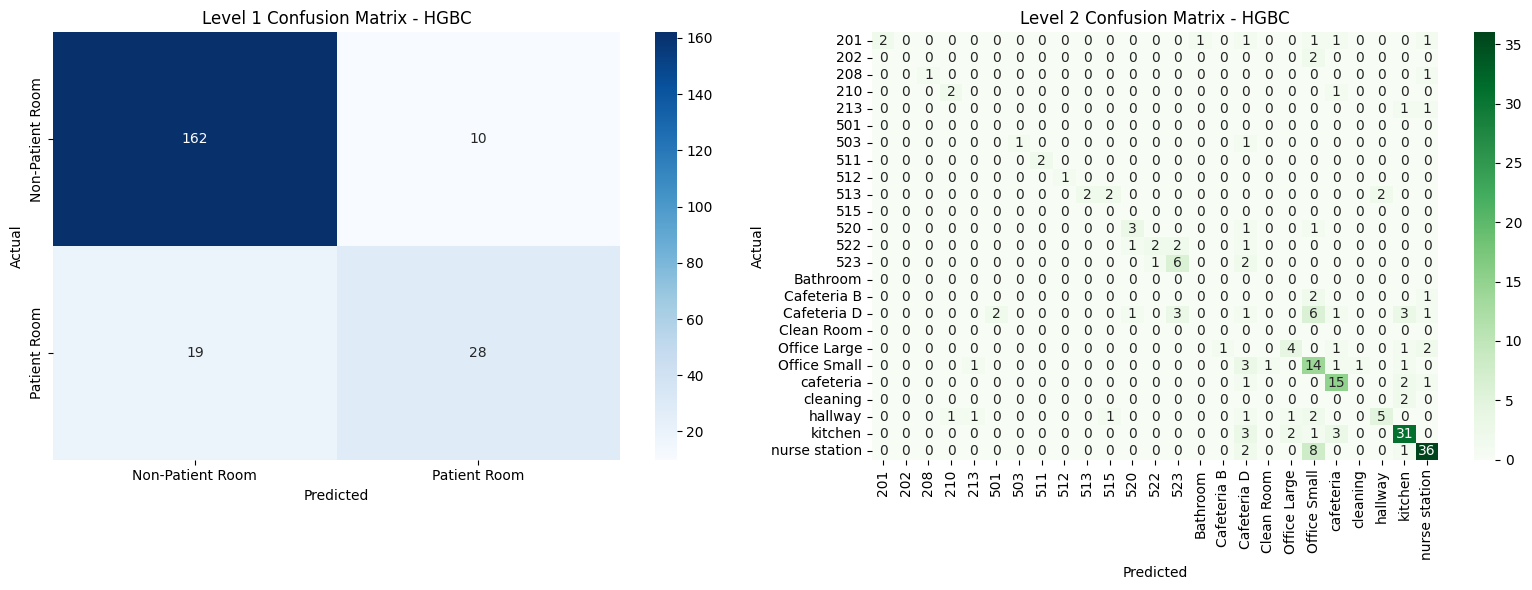

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Pilih model terbaik (XGBoost untuk level 1, HGBC untuk level 2)
best_model_name = "HGBC"

# Train model terbaik
clf_level1 = create_model(best_model_name)
clf_level1.fit(X_train, y_l1_train)
y_l1_pred = clf_level1.predict(X_test)

# Level 2 classifiers
clf_level2 = {}
le_level2 = {}

for level1_name in hierarchy.keys():
    level1_idx = le_level1.transform([level1_name])[0]
    mask_train = y_l1_train == level1_idx
    
    if mask_train.sum() > 0:
        le_level2[level1_name] = LabelEncoder()
        y_subset = le_level2[level1_name].fit_transform(y_train[mask_train])
        
        clf_level2[level1_name] = create_model(best_model_name)
        clf_level2[level1_name].fit(X_train[mask_train], y_subset)

# Hierarchical prediction for Level 2
y_pred_rooms = []
for i, level1_pred in enumerate(y_l1_pred):
    level1_name = le_level1.inverse_transform([level1_pred])[0]
    pred_encoded = clf_level2[level1_name].predict(X_test[i:i+1])[0]
    room = le_level2[level1_name].inverse_transform([pred_encoded])[0]
    y_pred_rooms.append(room)

# Confusion Matrix Level 1
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_level1 = confusion_matrix(y_l1_test, y_l1_pred)
sns.heatmap(cm_level1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_level1.classes_, 
            yticklabels=le_level1.classes_,
            ax=axes[0])
axes[0].set_title(f'Level 1 Confusion Matrix - {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix Level 2
cm_level2 = confusion_matrix(y_test_rooms, y_pred_rooms)
unique_rooms = sorted(set(y_test_rooms) | set(y_pred_rooms))
sns.heatmap(cm_level2, annot=True, fmt='d', cmap='Greens', 
            xticklabels=unique_rooms, 
            yticklabels=unique_rooms,
            ax=axes[1])
axes[1].set_title(f'Level 2 Confusion Matrix - {best_model_name}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()